In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm tensorflow transformers torch optuna


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Mounted at /content/drive


Installing IBM Time Series Foundation Model library...
IBM TSFM installed. Please restart runtime and run again.
CUDA available with 1 device(s)
Current device: 0
Device name: Tesla T4
TensorFlow GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuration set. Using IBM Granite TSFM: ibm-granite/granite-timeseries-ttm-r2
STLF FORECASTING PIPELINE WITH IBM GRANITE TSFM - CUDA ENABLED

[STEP 1] Loading data...
Loading training data from /content/drive/MyDrive/Colab Notebooks/short-term-load-forecasting (1)/train.csv...
Original data shape: (2582976, 5)
Available columns: ['building_id', 'window_id', 'timestamp', 'meter_reading', 'role']
First few rows:
  building_id  window_id            timestamp  meter_reading   role
0        H001          1  2018-07-01 00:00:00         1.4081  input
1        H001          1  2018-07-01 01:00:00         0.8785  input
2        H001          1  2018-07-01 02:00:00         0.4504  input
3        H001          1  2018-07-0

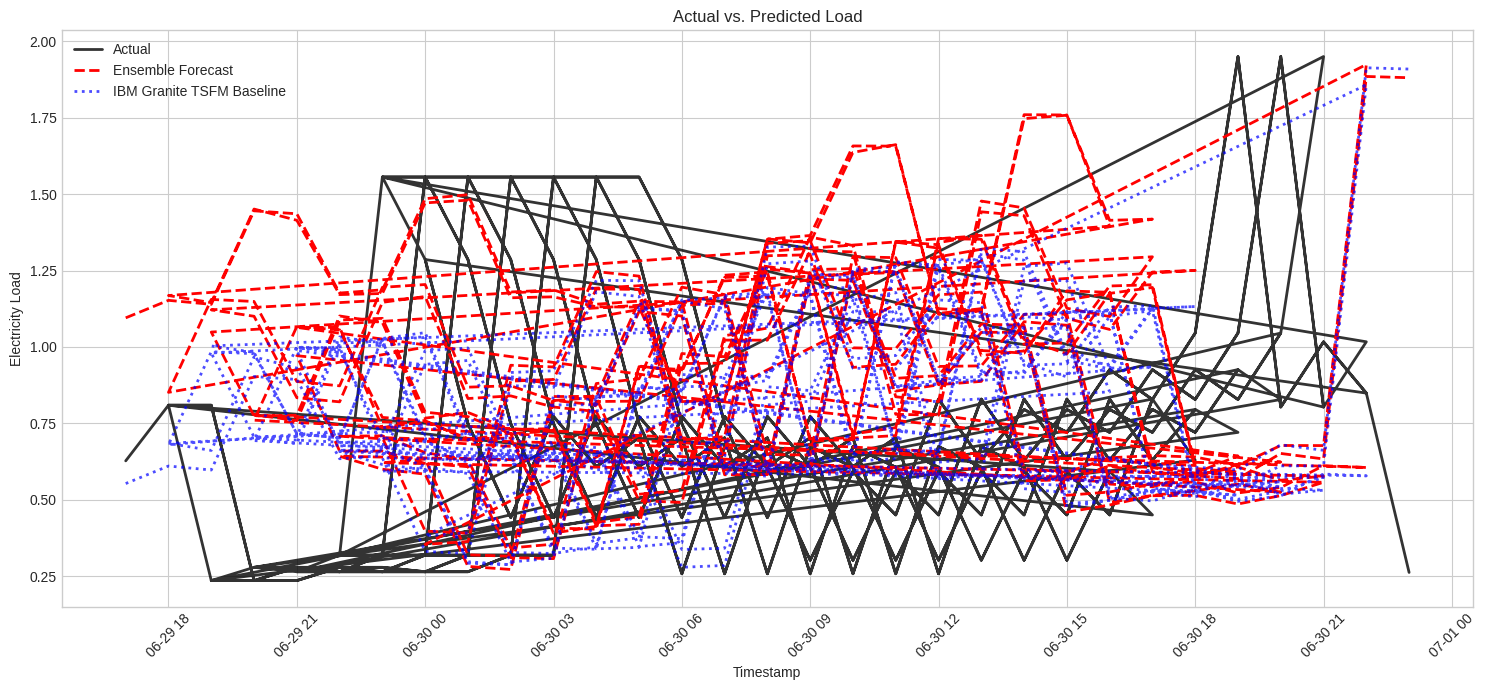

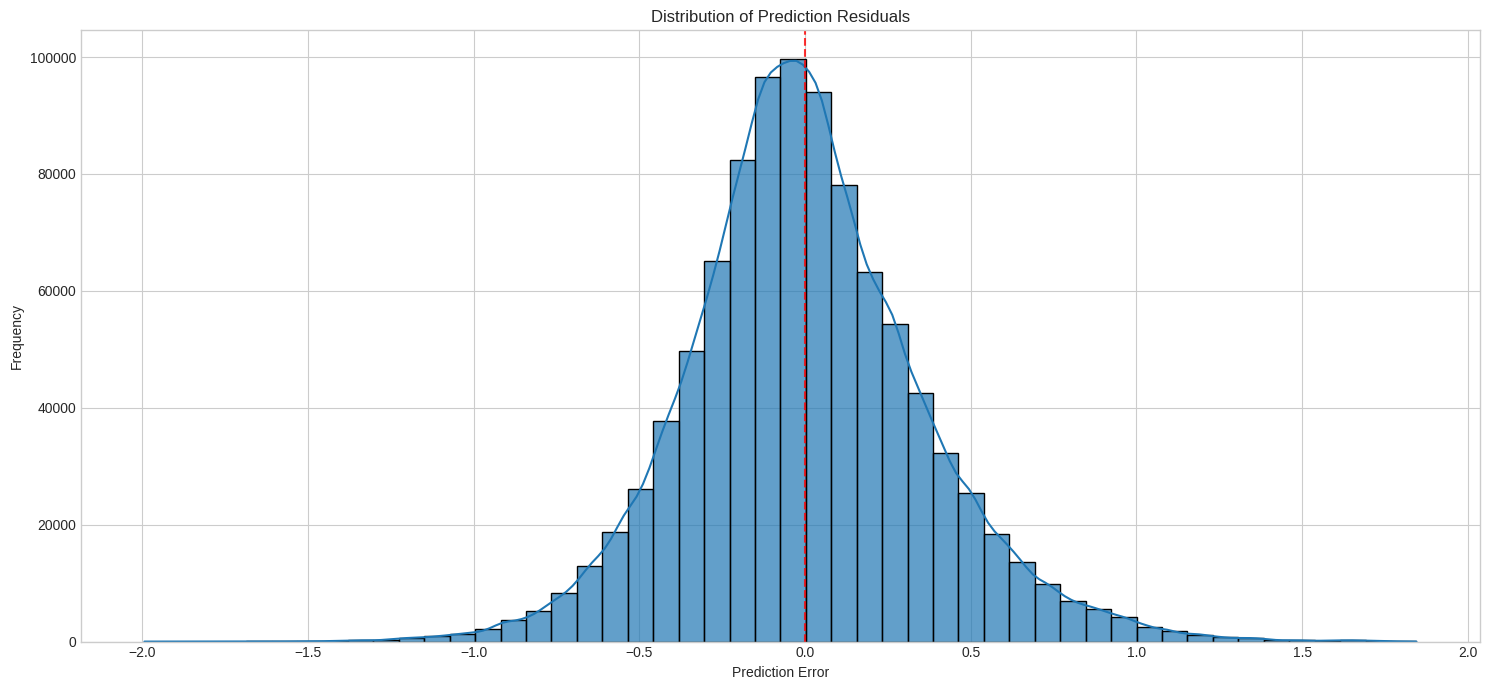

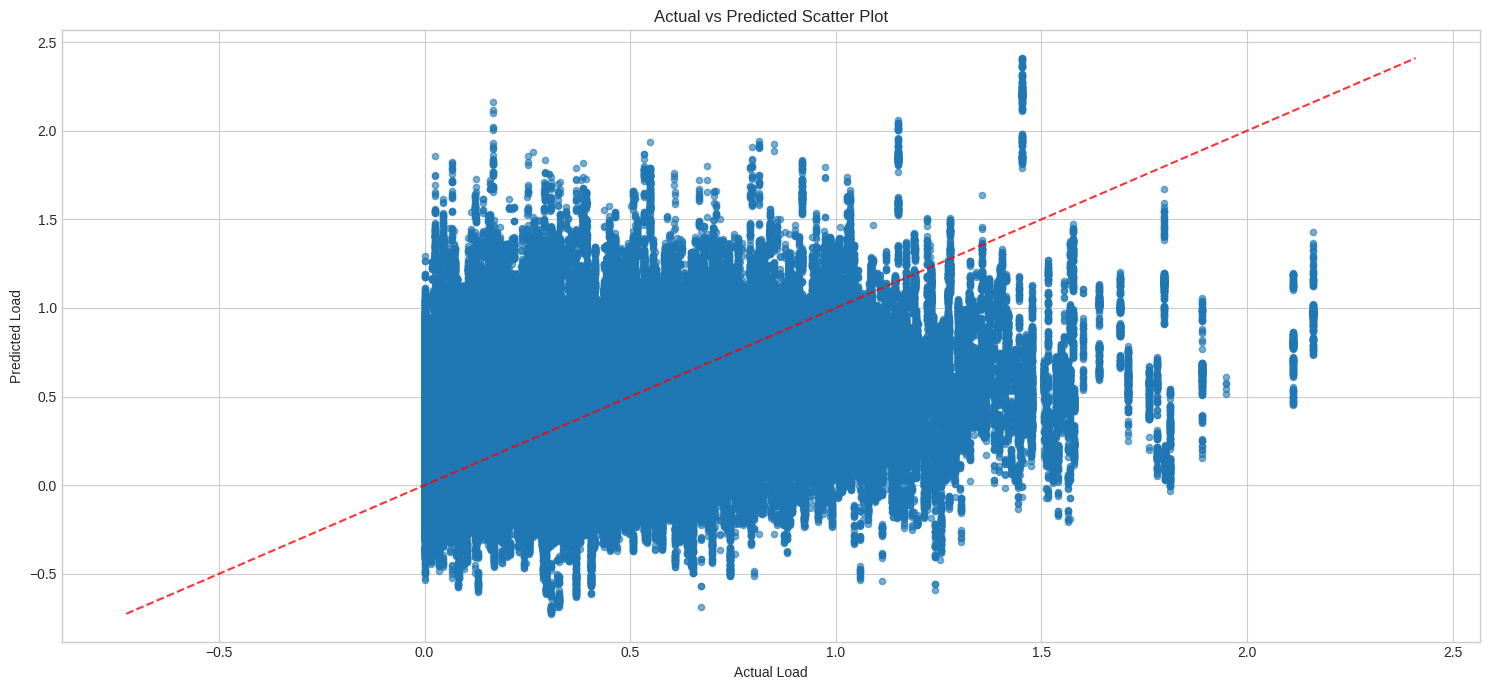

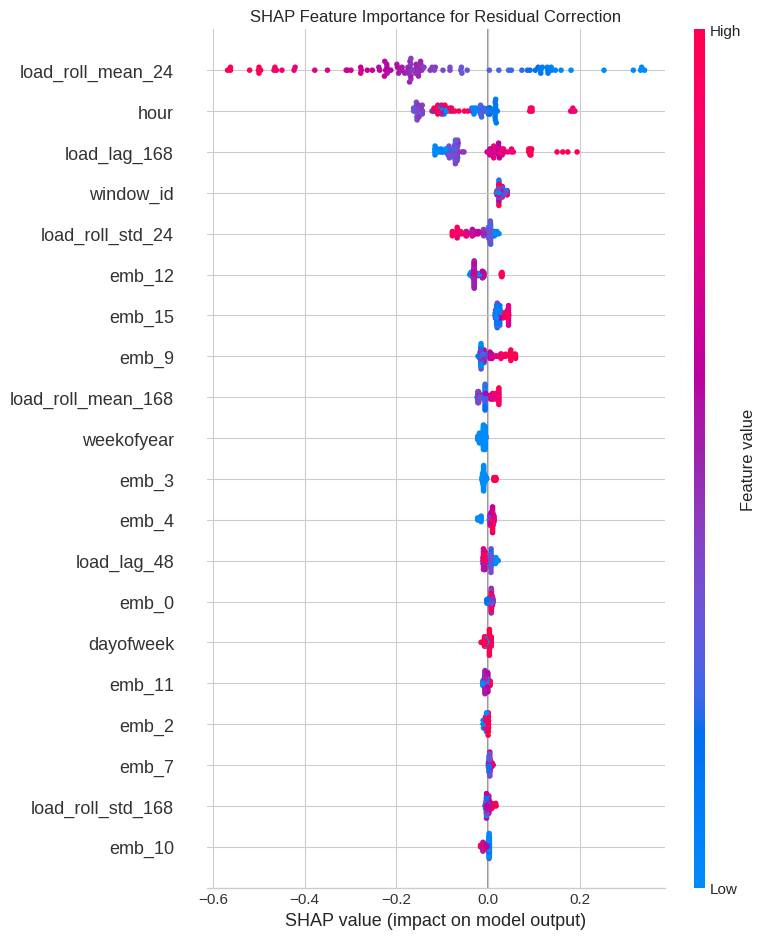

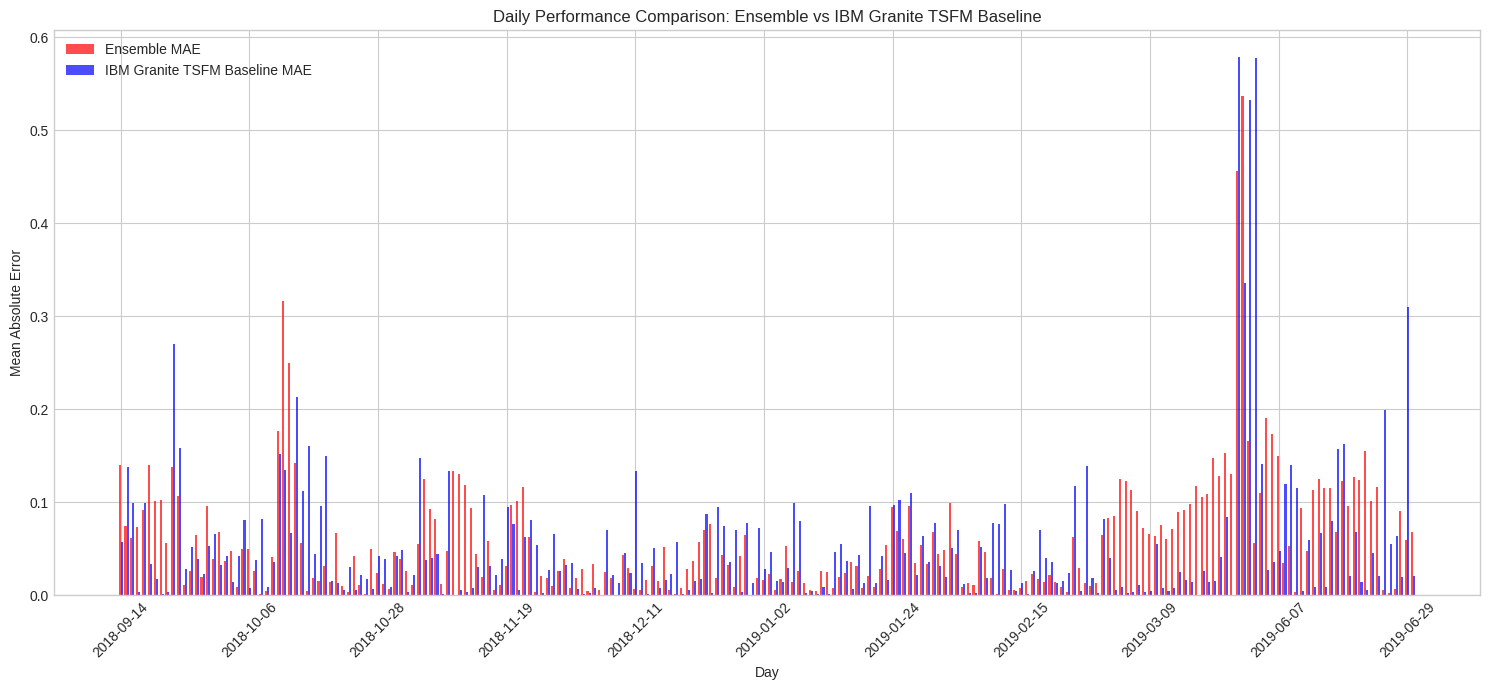


[STEP 7] Generating comprehensive report...

COMPREHENSIVE FORECASTING REPORT

DATA OVERVIEW:
- Total predictions: 968,112
- Time period: 2018-09-14 06:00:00 to 2019-06-30 23:00:00
- Actual load range: 0.00 - 2.16
- Predicted load range: -0.73 - 2.41

PERFORMANCE METRICS:
- Root Mean Square Error (RMSE): 0.3560
- Mean Absolute Error (MAE): 0.2714
- Mean Squared Error (MSE): 0.1267
- Improvement over IBM Granite TSFM baseline: 55.83%

MODEL ARCHITECTURE:
- Foundation Model: IBM Granite TSFM (granite-timeseries-ttm-r2)
- Context Length: 168 hours
- Prediction Horizon: 24 hours
- Ensemble Models: ['XGBoost', 'LightGBM', 'SVR', 'LSTM']
- Feature Space Dimensions: 49

PREDICTION QUALITY:
- Mean residual: -0.0000
- Residual standard deviation: 0.3560
- Predictions within ±10% of actual: 9.9%
- Predictions within ±20% of actual: 19.5%

[STEP 8] Saving models and results...

Saving models and results...
  - Saved XGBoost model
  - Saved LightGBM model
  - Saved SVR model
  - Saved LSTM model


In [ ]:
# -*- coding: utf-8 -*-
"""
STLF_Forecasting_Complete.py - CUDA Enabled
Description:
A complete, self-contained Jupyter Notebook pipeline for Short-Term Load Forecasting (STLF).
This script implements a two-layered architecture:
1. Foundation Backbone (IBM Granite TSFM): Utilizes the pre-trained
   ibm-granite/granite-timeseries-ttm-r2 model for core forecasting and embedding extraction.
2. Ensemble Layer (Stacked Meta-Learner): A set of specialized models (GBM, GPR,
   RNN, SVR) trained on the residuals from the backbone, using a combination of
   TSFM embeddings and rich metadata.
Everything is contained in this single script - no dependencies on previous cells.
"""

# =============================================================================
# 1. IMPORTS & CONFIGURATION
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
import optuna
import shap
import joblib
import os
import torch
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Install and import IBM TSFM library
try:
    from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
    from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
    from transformers import AutoConfig, AutoModelForSeq2SeqLM, AutoTokenizer
    IBM_TSFM_AVAILABLE = True
    print("IBM TSFM library loaded successfully")
except ImportError:
    print("Installing IBM Time Series Foundation Model library...")
    try:
        import subprocess
        import sys
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "git+https://github.com/IBM/tsfm.git"
        ])
        print("IBM TSFM installed. Please restart runtime and run again.")
        IBM_TSFM_AVAILABLE = False
    except Exception as e:
        print(f"Failed to install IBM TSFM: {e}")
        print("Will use fallback implementation")
        IBM_TSFM_AVAILABLE = False

# Import Hugging Face transformers as backup
try:
    from transformers import AutoProcessor, AutoModel
    HF_AVAILABLE = True
except ImportError:
    print("Warning: transformers library not available. Install with: pip install transformers torch")
    HF_AVAILABLE = False

# Suppress Optuna's trial logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# CUDA CONFIGURATION - NEW ADDITION
# =============================================================================
# Configure CUDA and GPU settings
if torch.cuda.is_available():
    print(f"CUDA available with {torch.cuda.device_count()} device(s)")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
    torch.cuda.set_device(0)  # Set default device
else:
    print("CUDA not available, using CPU")

# Configure TensorFlow GPU
if tf.config.list_physical_devices('GPU'):
    print("TensorFlow GPU devices:", tf.config.list_physical_devices('GPU'))
    # Enable memory growth to avoid taking all GPU memory
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("TensorFlow will use CPU")

# =============================================================================
# 2. CONFIGURATION CLASS
# =============================================================================
class Config:
    """Configuration class for holding all pipeline parameters."""
    RANDOM_SEED = 42
    N_HOURS_PAST = 168  # Context length for our use case (will be adapted for the model)
    N_HOURS_FUTURE = 24  # Prediction horizon (will be adapted from model output)
    TRAIN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/short-term-load-forecasting (1)/train.csv"
    METADATA_PATH = "/content/drive/MyDrive/Colab Notebooks/short-term-load-forecasting (1)/metadata.csv"
    RESULTS_DIR = "/content/drive/MyDrive/Results"
    ENABLE_OPTUNA = True
    N_OPTUNA_TRIALS = 10
    N_SPLITS = 3
    PLOT_FONT_SIZE = 12
    PLOT_FIG_SIZE = (15, 7)
    # IBM Granite Model
    HF_MODEL_NAME = "ibm-granite/granite-timeseries-ttm-r2"

    # Add fallback paths for easier testing
    FALLBACK_TRAIN_DATA_PATH = "train.csv"
    FALLBACK_METADATA_PATH = "metadata.csv"

# Set seeds and create directories
np.random.seed(Config.RANDOM_SEED)
tf.random.set_seed(Config.RANDOM_SEED)
torch.manual_seed(Config.RANDOM_SEED)
os.makedirs(Config.RESULTS_DIR, exist_ok=True)

# Set plot style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('default')

print(f"Configuration set. Using IBM Granite TSFM: {Config.HF_MODEL_NAME}")

# =============================================================================
# 3. DATA LOADING FUNCTIONS
# =============================================================================
def load_data(train_path, metadata_path=None):
    """
    Loads and processes the building energy consumption data.
    """
    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Train data file not found at {train_path}")

    print(f"Loading training data from {train_path}...")

    # Load the time series data
    df = pd.read_csv(train_path)
    print(f"Original data shape: {df.shape}")
    print(f"Available columns: {list(df.columns)}")
    print("First few rows:")
    print(df.head())

    # Parse timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Rename meter_reading to load for consistency
    if 'meter_reading' in df.columns:
        df = df.rename(columns={'meter_reading': 'load'})
        print("Renamed 'meter_reading' to 'load'")

    # Select building to focus on
    buildings = df['building_id'].unique()
    print(f"Available buildings: {buildings}")

    # Use the first building
    selected_building = buildings[0]
    print(f"Using building: {selected_building}")

    # Filter data for the selected building
    df_building = df[df['building_id'] == selected_building].copy()

    # Set timestamp as index and sort
    df_building = df_building.set_index('timestamp').sort_index()

    # Remove building_id column
    if 'building_id' in df_building.columns:
        df_building = df_building.drop(['building_id'], axis=1)

    # Load and merge metadata if available
    if metadata_path and os.path.exists(metadata_path):
        print(f"Loading metadata from {metadata_path}...")
        metadata = pd.read_csv(metadata_path)
        print(f"Metadata shape: {metadata.shape}")
        print("Metadata columns:", list(metadata.columns))

        # Get metadata for the selected building
        building_meta = metadata[metadata['building_id'] == selected_building]
        if len(building_meta) > 0:
            building_meta = building_meta.iloc[0]
            # Add constant metadata features to each time step
            for col in metadata.columns:
                if col != 'building_id':
                    df_building[col] = building_meta[col]
            print("Added metadata features to the dataset")
        else:
            print(f"No metadata found for building {selected_building}")

    print(f"Final dataset shape: {df_building.shape}")
    print(f"Date range: {df_building.index.min()} to {df_building.index.max()}")
    print(f"Load column stats:\n{df_building['load'].describe()}")

    return df_building

# =============================================================================
# 4. FEATURE ENGINEERING
# =============================================================================
def create_features(df):
    """Creates a rich set of time-series features."""
    print("Engineering features...")
    df_feat = df.copy()

    # Time-based features
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['dayofmonth'] = df_feat.index.day
    df_feat['weekofyear'] = df_feat.index.isocalendar().week.astype(int)
    df_feat['month'] = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['year'] = df_feat.index.year

    # Lag features
    for lag in [24, 48, 168]:
        df_feat[f'load_lag_{lag}'] = df_feat['load'].shift(lag)

    # Rolling window features
    for window in [24, 168]:
        df_feat[f'load_roll_mean_{window}'] = df_feat['load'].shift(1).rolling(window=window).mean()
        df_feat[f'load_roll_std_{window}'] = df_feat['load'].shift(1).rolling(window=window).std()

    # Handle categorical features
    categorical_cols = df_feat.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(f"Encoding categorical columns: {list(categorical_cols)}")
        for col in categorical_cols:
            if df_feat[col].nunique() < 50:  # Only encode if not too many categories
                encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
                encoded = encoder.fit_transform(df_feat[[col]])
                encoded_df = pd.DataFrame(encoded, index=df_feat.index,
                                        columns=encoder.get_feature_names_out([col]))
                df_feat = pd.concat([df_feat, encoded_df], axis=1).drop(col, axis=1)
            else:
                df_feat = df_feat.drop(col, axis=1)
                print(f"Dropped categorical column {col} (too many categories)")

    # Remove rows with NaN values
    initial_shape = df_feat.shape[0]
    df_feat = df_feat.dropna()
    final_shape = df_feat.shape[0]
    print(f"Dropped {initial_shape - final_shape} rows due to NaN values")
    print(f"Feature engineering complete. Final shape: {df_feat.shape}")

    return df_feat

# =============================================================================
# 5. IBM GRANITE TSFM MODEL WRAPPER (CUDA ENABLED)
# =============================================================================
class GraniteTSFM:
    """A wrapper for the IBM Granite Time Series Foundation Model - CUDA Enabled."""

    def __init__(self, model_name=Config.HF_MODEL_NAME):
        self.model_name = model_name
        self.use_fallback = False
        self.use_alternative = False

        if not IBM_TSFM_AVAILABLE:
            print("IBM TSFM library not available. Using fallback implementation.")
            self.use_fallback = True
            return

        try:
            print(f"Loading IBM Granite TSFM: {model_name}")
            # CHANGE: Force CUDA device selection
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
            print(f"Using device: {self.device}")

            # Load model configuration
            config = AutoConfig.from_pretrained(model_name)

            # Important: Keep the original prediction length from pretrained model
            # and adapt our pipeline instead
            self.original_prediction_length = getattr(config, 'prediction_length', 96)
            print(f"Model's original prediction length: {self.original_prediction_length}")

            # Set up model parameters - use original config values
            config.context_length = getattr(config, 'context_length', 512)  # Use model's default
            config.num_input_channels = 1  # Single time series

            # CHANGE: Explicitly move model to CUDA and set torch device
            self.model = TinyTimeMixerForPrediction.from_pretrained(
                model_name,
                config=config
            ).to(self.device)

            if torch.cuda.is_available():
                torch.cuda.set_device(0)  # Set default CUDA device

            self.model.eval()  # Set to evaluation mode

            # Initialize preprocessor with model's original parameters
            self.preprocessor = TimeSeriesPreprocessor(
                context_length=config.context_length,
                prediction_length=self.original_prediction_length,
                scaling=True,
                scaling_type="standard"
            )

            print(f"IBM Granite TSFM loaded successfully on device: {self.device}")
            print(f"Model context length: {config.context_length}, prediction length: {self.original_prediction_length}")

        except Exception as e:
            print(f"Failed to load IBM TSFM model: {e}")
            print("Using enhanced fallback implementation")
            self.use_fallback = True

    def _prepare_data_for_tsfm(self, past_values_list):
        """Prepare data in the correct format for IBM TSFM."""
        try:
            # Convert list to numpy array
            past_values = np.array(past_values_list)

            # Adjust context length to match model's expectation
            model_context_length = getattr(self.model.config, 'context_length', 512)

            if past_values.shape[1] != model_context_length:
                if past_values.shape[1] > model_context_length:
                    # Truncate to model's expected length
                    past_values = past_values[:, -model_context_length:]
                else:
                    # Pad with zeros if needed
                    pad_length = model_context_length - past_values.shape[1]
                    padding = np.zeros((past_values.shape[0], pad_length))
                    past_values = np.concatenate([padding, past_values], axis=1)

            # Ensure shape is (batch_size, context_length, num_channels)
            if past_values.ndim == 2:
                past_values = past_values[:, :, np.newaxis]

            return torch.tensor(past_values, dtype=torch.float32).to(self.device)

        except Exception as e:
            print(f"Data preparation failed: {e}")
            # Return simple tensor format as fallback
            past_values = np.array(past_values_list)
            if past_values.ndim == 2:
                past_values = past_values[:, :, np.newaxis]
            return torch.tensor(past_values, dtype=torch.float32).to(self.device)

    def predict(self, past_values_list):
        """Generates forecasts using the IBM TSFM model."""
        if self.use_fallback:
            return self._fallback_predict(past_values_list)

        try:
            # Prepare data
            inputs = self._prepare_data_for_tsfm(past_values_list)

            # Generate predictions using the model
            with torch.no_grad():
                # Create input dictionary for the model
                model_inputs = {
                    'past_values': inputs,
                }

                # Forward pass through the model
                outputs = self.model(**model_inputs)

                # Extract predictions
                if hasattr(outputs, 'prediction_outputs'):
                    predictions = outputs.prediction_outputs
                elif hasattr(outputs, 'last_hidden_state'):
                    predictions = outputs.last_hidden_state
                else:
                    # If outputs is a tensor directly
                    predictions = outputs

                # Convert to numpy
                predictions_np = predictions.cpu().numpy()

                # Ensure correct shape: (batch_size, prediction_length)
                if predictions_np.ndim == 3 and predictions_np.shape[2] == 1:
                    predictions_np = predictions_np.squeeze(-1)

                # Adapt to our target prediction length
                if predictions_np.shape[1] != Config.N_HOURS_FUTURE:
                    if predictions_np.shape[1] > Config.N_HOURS_FUTURE:
                        # Truncate to our target length
                        predictions_np = predictions_np[:, :Config.N_HOURS_FUTURE]
                    else:
                        # Repeat pattern if model predicts less than we need
                        repeat_factor = (Config.N_HOURS_FUTURE // predictions_np.shape[1]) + 1
                        extended_pred = np.tile(predictions_np, (1, repeat_factor))
                        predictions_np = extended_pred[:, :Config.N_HOURS_FUTURE]

                return predictions_np

        except Exception as e:
            print(f"TSFM prediction failed: {e}, using fallback")
            return self._fallback_predict(past_values_list)

    def extract_embeddings(self, past_values_list):
        """Extracts embeddings from the TSFM encoder."""
        if self.use_fallback:
            return self._fallback_embeddings(past_values_list)

        try:
            # Prepare data
            inputs = self._prepare_data_for_tsfm(past_values_list)

            # Extract embeddings
            with torch.no_grad():
                # Get encoder outputs
                model_inputs = {
                    'past_values': inputs,
                }

                # Forward pass to get hidden states
                if hasattr(self.model, 'encoder'):
                    outputs = self.model.encoder(**model_inputs, output_hidden_states=True)
                else:
                    # Some models might not have separate encoder
                    outputs = self.model(**model_inputs, output_hidden_states=True)

                # Extract embeddings from the last hidden state
                if hasattr(outputs, 'last_hidden_state'):
                    hidden_states = outputs.last_hidden_state
                elif hasattr(outputs, 'hidden_states'):
                    hidden_states = outputs.hidden_states[-1]  # Last layer
                else:
                    # Fallback: try to get embeddings directly
                    if hasattr(self.model, 'encoder'):
                        hidden_states = self.model.encoder(**model_inputs)
                    else:
                        hidden_states = self.model(**model_inputs)

                # Pool over time dimension to get fixed-size embeddings
                embeddings = hidden_states.mean(dim=1)  # Average pooling

                return embeddings.cpu().numpy()

        except Exception as e:
            print(f"Embedding extraction failed: {e}, using fallback")
            return self._fallback_embeddings(past_values_list)

    def _fallback_predict(self, past_values_list):
        """Enhanced baseline prediction method with seasonal patterns."""
        predictions = []
        for past_values in past_values_list:
            try:
                past_values = np.asarray(past_values).flatten()  # Ensure 1D array

                # Use seasonal naive with trend
                last_day = past_values[-24:] if len(past_values) >= 24 else past_values
                last_week = past_values[-168:-144] if len(past_values) >= 168 else last_day

                # Calculate trend
                if len(past_values) >= 168:
                    trend = np.mean(last_day) - np.mean(last_week)
                else:
                    trend = np.mean(np.diff(past_values)) if len(past_values) > 1 else 0

                # Create seasonal pattern
                if len(last_day) == 24:
                    seasonal_pred = np.tile(last_day, (Config.N_HOURS_FUTURE // 24) + 1)[:Config.N_HOURS_FUTURE]
                else:
                    seasonal_pred = np.repeat(np.mean(last_day), Config.N_HOURS_FUTURE)

                # Apply trend and add small noise for realism
                pred = seasonal_pred + trend + np.random.normal(0, 0.01, Config.N_HOURS_FUTURE)
                predictions.append(pred)

            except Exception as e:
                # Ultra-simple fallback
                mean_val = np.mean(past_values) if len(past_values) > 0 else 0
                pred = np.full(Config.N_HOURS_FUTURE, mean_val)
                predictions.append(pred)

        return np.array(predictions)

    def _fallback_embeddings(self, past_values_list):
        """Enhanced statistical features as embeddings with proper error handling."""
        embeddings = []

        for past_values in past_values_list:
            try:
                # Ensure we have a proper 1D numpy array
                past_values = np.asarray(past_values).flatten()

                if len(past_values) == 0:
                    # Handle empty array case
                    features = np.zeros(16)
                else:
                    # Safe statistical calculations
                    mean_val = np.mean(past_values)
                    std_val = np.std(past_values)

                    # Basic statistics
                    features = [
                        mean_val,
                        std_val,
                        np.min(past_values),
                        np.max(past_values),
                        np.median(past_values),
                        np.var(past_values),

                        # Recent statistics (last day)
                        np.mean(past_values[-24:]) if len(past_values) >= 24 else mean_val,
                        np.std(past_values[-24:]) if len(past_values) >= 24 else std_val,

                        # Weekly statistics
                        np.mean(past_values[-168:]) if len(past_values) >= 168 else mean_val,

                        # Trend features
                        np.mean(np.diff(past_values)) if len(past_values) > 1 else 0,
                        np.std(np.diff(past_values)) if len(past_values) > 1 else 0,

                        # Seasonal correlation (daily) - safe version
                        0 if len(past_values) <= 48 else (
                            np.corrcoef(past_values[:-24], past_values[24:])[0,1]
                            if not np.isnan(np.corrcoef(past_values[:-24], past_values[24:])[0,1])
                            else 0
                        ),

                        # Additional features
                        np.percentile(past_values, 25),
                        np.percentile(past_values, 75),

                        # Above mean ratio - safe version
                        np.sum(past_values > mean_val) / len(past_values),

                        # Volatility measure
                        np.sum(np.abs(np.diff(past_values))) / len(past_values) if len(past_values) > 1 else 0
                    ]

                # Convert to numpy array and handle any remaining NaN/inf values
                features = np.array(features)
                features = np.nan_to_num(features, nan=0.0, posinf=1.0, neginf=-1.0)

                embeddings.append(features)

            except Exception as e:
                print(f"Error in embedding calculation: {e}")
                # Ultra-simple fallback - zeros
                embeddings.append(np.zeros(16))

        return np.array(embeddings)

# =============================================================================
# 6. DATA PREPARATION FOR SEQUENTIAL MODELS
# =============================================================================
def create_sequences(df, past_len, future_len):
    """Creates sequences of past data and future targets for time series forecasting."""
    ts_data, metadata, targets = [], [], []
    load_values = df['load'].values
    metadata_cols = df.drop('load', axis=1)

    for i in range(len(df) - past_len - future_len + 1):
        past_end = i + past_len
        ts_data.append(load_values[i:past_end])
        metadata.append(metadata_cols.iloc[past_end-1].values)
        future_end = past_end + future_len
        targets.append(load_values[past_end:future_end])

    return {
        'past_ts': np.array(ts_data),
        'metadata': np.array(metadata),
        'targets': np.array(targets),
        'metadata_cols': list(metadata_cols.columns)
    }

# =============================================================================
# 7. ENSEMBLE MODEL TRAINING (CUDA ENABLED)
# =============================================================================
def create_lstm_model(input_shape):
    """Creates a simple LSTM model for the ensemble - CUDA enabled."""
    # CHANGE: Set TensorFlow to use GPU
    strategy = tf.distribute.MirroredStrategy() if tf.config.list_physical_devices('GPU') else tf.distribute.get_strategy()

    with strategy.scope():
        model = Sequential([
            Input(shape=(1, input_shape)),
            LSTM(50, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')

    return model

def train_specialized_models(X_train, y_train, X_test):
    """Trains each specialized model in the ensemble layer - CUDA enabled."""
    print("Training specialized ensemble models...")

    # CHANGE: Enable GPU acceleration for tree-based models
    models = {
        "XGBoost": XGBRegressor(
            random_state=Config.RANDOM_SEED,
            verbosity=0,
            tree_method='gpu_hist' if torch.cuda.is_available() else 'hist',  # GPU for XGBoost
            gpu_id=0 if torch.cuda.is_available() else None
        ),
        "LightGBM": LGBMRegressor(
            random_state=Config.RANDOM_SEED,
            verbose=-1,
            device='gpu' if torch.cuda.is_available() else 'cpu'  # GPU for LightGBM
        ),
        "SVR": SVR(),  # CPU only
        "LSTM": create_lstm_model(X_train.shape[1]),  # Already CUDA-enabled
    }

    predictions, trained_models = {}, {}

    for name, model in models.items():
        try:
            print(f"  - Training {name}...")
            if name == "LSTM":
                X_train_rnn = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
                X_test_rnn = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
                model.fit(X_train_rnn, y_train, epochs=20, batch_size=32, verbose=0)
                predictions[name] = model.predict(X_test_rnn).flatten()
            else:
                model.fit(X_train, y_train)
                predictions[name] = model.predict(X_test)
            trained_models[name] = model
        except Exception as e:
            print(f"  - Failed to train {name}: {e}")
            # Use simple baseline for failed models
            predictions[name] = np.mean(y_train) * np.ones(X_test.shape[0])
            trained_models[name] = None

    return trained_models, pd.DataFrame(predictions, index=range(X_test.shape[0]))

# =============================================================================
# 8. HYPERPARAMETER TUNING & STACKING (CUDA ENABLED)
# =============================================================================
def optimize_model_hyperparameters(model_name, X_train, y_train):
    """Uses Optuna to find the best hyperparameters - CUDA enabled."""
    print(f"Optimizing hyperparameters for {model_name} with Optuna...")

    def objective(trial):
        try:
            if model_name == "XGBoost":
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                    'max_depth': trial.suggest_int('max_depth', 3, 8),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
                    # CHANGE: Add GPU parameters for XGBoost
                    'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
                    'gpu_id': 0 if torch.cuda.is_available() else None
                }
                model = XGBRegressor(**params, random_state=Config.RANDOM_SEED, verbosity=0)
            elif model_name == "LightGBM":
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
                    'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                    # CHANGE: Add GPU parameter for LightGBM
                    'device': 'gpu' if torch.cuda.is_available() else 'cpu'
                }
                model = LGBMRegressor(**params, random_state=Config.RANDOM_SEED, verbose=-1)

            # Simple validation split
            split_idx = int(0.8 * len(X_train))
            X_t, X_v = X_train[:split_idx], X_train[split_idx:]
            y_t, y_v = y_train[:split_idx], y_train[split_idx:]

            model.fit(X_t, y_t)
            pred = model.predict(X_v)
            return mean_squared_error(y_v, pred)
        except:
            return float('inf')

    try:
        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=Config.N_OPTUNA_TRIALS)
        print(f"Best params for {model_name}: {study.best_params}")
        return study.best_params
    except Exception as e:
        print(f"Optuna optimization failed: {e}, using default parameters")
        return {}

def train_meta_learner(ensemble_predictions, y_true):
    """Trains a meta-learner on the predictions of the ensemble models."""
    print("Training meta-learner for stacking...")
    meta_learner = LinearRegression()
    try:
        meta_learner.fit(ensemble_predictions, y_true)
    except Exception as e:
        print(f"Meta-learner training failed: {e}")
        # Simple averaging fallback
        meta_learner = None
    return meta_learner

# =============================================================================
# 9. MAIN PIPELINE EXECUTION
# =============================================================================
def run_pipeline(df, tsfm_model):
    """Main function to run the entire forecasting pipeline."""
    print("Creating sequences...")
    sequences = create_sequences(df, Config.N_HOURS_PAST, Config.N_HOURS_FUTURE)

    if len(sequences['past_ts']) < Config.N_SPLITS * 2:
        print(f"Not enough data for {Config.N_SPLITS} splits, reducing to 2 splits")
        n_splits = min(2, len(sequences['past_ts']) // 2)
    else:
        n_splits = Config.N_SPLITS

    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_results = []

    print(f"Starting {n_splits} fold cross-validation...")
    print(f"Total sequences available: {len(sequences['past_ts'])}")

    for fold, (train_index, test_index) in enumerate(tscv.split(sequences['past_ts'])):
        print(f"\n===== FOLD {fold+1}/{n_splits} =====")
        print(f"Train samples: {len(train_index)}, Test samples: {len(test_index)}")

        # Split sequential data
        past_ts_train = sequences['past_ts'][train_index]
        past_ts_test = sequences['past_ts'][test_index]
        meta_train = sequences['metadata'][train_index]
        meta_test = sequences['metadata'][test_index]
        y_train_seq = sequences['targets'][train_index]
        y_test_seq = sequences['targets'][test_index]

        print(f"Data shapes - Train TS: {past_ts_train.shape}, Test TS: {past_ts_test.shape}")
        print(f"Target shapes - Train: {y_train_seq.shape}, Test: {y_test_seq.shape}")
        print(f"Metadata shapes - Train: {meta_train.shape}, Test: {meta_test.shape}")

        try:
            # Get TSFM forecasts
            print("Getting IBM Granite TSFM backbone forecasts...")
            tsfm_preds = tsfm_model.predict(past_ts_test.tolist())
            print(f"TSFM predictions shape: {tsfm_preds.shape}")

            # Ensure predictions have the right shape
            if tsfm_preds.ndim == 1:
                tsfm_preds = tsfm_preds.reshape(-1, Config.N_HOURS_FUTURE)
            elif tsfm_preds.shape[1] != Config.N_HOURS_FUTURE:
                tsfm_preds = tsfm_preds[:, :Config.N_HOURS_FUTURE]

            # Ensure we have the right number of predictions
            if tsfm_preds.shape[0] != len(test_index):
                print(f"Warning: Prediction count mismatch. Expected {len(test_index)}, got {tsfm_preds.shape[0]}")
                if tsfm_preds.shape[0] > len(test_index):
                    tsfm_preds = tsfm_preds[:len(test_index)]
                else:
                    last_pred = tsfm_preds[-1:].repeat(len(test_index) - tsfm_preds.shape[0], axis=0)
                    tsfm_preds = np.concatenate([tsfm_preds, last_pred], axis=0)

            # Get TSFM embeddings
            print("Extracting IBM Granite TSFM embeddings...")
            embeddings_train = tsfm_model.extract_embeddings(past_ts_train.tolist())
            embeddings_test = tsfm_model.extract_embeddings(past_ts_test.tolist())

            print(f"Embeddings shapes - Train: {embeddings_train.shape}, Test: {embeddings_test.shape}")

            # Ensure embeddings are 2D and match sample counts
            def fix_embeddings_shape(embeddings, expected_samples):
                """Fix embedding dimensionality and sample count."""
                # Handle 3D embeddings by flattening
                if embeddings.ndim == 3:
                    batch_size = embeddings.shape[0]
                    embeddings = embeddings.reshape(batch_size, -1)
                elif embeddings.ndim == 1:
                    embeddings = embeddings.reshape(1, -1)

                # Handle sample count mismatch
                if embeddings.shape[0] != expected_samples:
                    if embeddings.shape[0] > expected_samples:
                        embeddings = embeddings[:expected_samples]
                    else:
                        # Repeat last embedding
                        repeats_needed = expected_samples - embeddings.shape[0]
                        last_emb = embeddings[-1:].repeat(repeats_needed, axis=0)
                        embeddings = np.concatenate([embeddings, last_emb], axis=0)

                return embeddings

            # Fix embeddings
            embeddings_train = fix_embeddings_shape(embeddings_train, len(train_index))
            embeddings_test = fix_embeddings_shape(embeddings_test, len(test_index))

            print(f"Fixed embeddings shapes - Train: {embeddings_train.shape}, Test: {embeddings_test.shape}")

            # Create enhanced feature set
            X_train_enhanced = np.concatenate([meta_train, embeddings_train], axis=1)
            X_test_enhanced = np.concatenate([meta_test, embeddings_test], axis=1)

            print(f"Enhanced features shape - Train: {X_train_enhanced.shape}, Test: {X_test_enhanced.shape}")

            # Calculate residuals for ensemble training
            tsfm_train_preds = tsfm_model.predict(past_ts_train.tolist())
            if tsfm_train_preds.ndim == 1:
                tsfm_train_preds = tsfm_train_preds.reshape(-1, Config.N_HOURS_FUTURE)

            # Ensure training predictions match
            if tsfm_train_preds.shape[0] != len(train_index):
                if tsfm_train_preds.shape[0] > len(train_index):
                    tsfm_train_preds = tsfm_train_preds[:len(train_index)]
                else:
                    last_pred = tsfm_train_preds[-1:].repeat(len(train_index) - tsfm_train_preds.shape[0], axis=0)
                    tsfm_train_preds = np.concatenate([tsfm_train_preds, last_pred], axis=0)

            residuals_train = (y_train_seq - tsfm_train_preds).mean(axis=1)
            residuals_test_mean = (y_test_seq - tsfm_preds).mean(axis=1)

            # Train ensemble models
            ensemble_models, ensemble_predictions = train_specialized_models(
                X_train_enhanced, residuals_train, X_test_enhanced
            )

            # Hyperparameter tuning
            if Config.ENABLE_OPTUNA:
                for model_name in ["XGBoost", "LightGBM"]:
                    if ensemble_models[model_name] is not None:
                        best_params = optimize_model_hyperparameters(
                            model_name, X_train_enhanced, residuals_train
                        )
                        if best_params:
                            ensemble_models[model_name].set_params(**best_params)
                            ensemble_models[model_name].fit(X_train_enhanced, residuals_train)
                            ensemble_predictions[model_name] = ensemble_models[model_name].predict(X_test_enhanced)

            # Train meta-learner
            meta_learner = train_meta_learner(ensemble_predictions, residuals_test_mean)

            if meta_learner is not None:
                final_residual_correction = meta_learner.predict(ensemble_predictions)
            else:
                # Simple averaging fallback
                final_residual_correction = ensemble_predictions.mean(axis=1)

            # Make final predictions
            final_preds = tsfm_preds + final_residual_correction[:, np.newaxis]

            # Store results
            start_idx = test_index[0]
            if start_idx < len(df) - Config.N_HOURS_FUTURE:
                # Create timestamps for all predictions
                timestamps = []
                for i, seq_start in enumerate(test_index):
                    if seq_start + Config.N_HOURS_PAST < len(df):
                        seq_start_time = df.index[seq_start + Config.N_HOURS_PAST]
                        seq_timestamps = pd.date_range(
                            start=seq_start_time,
                            periods=Config.N_HOURS_FUTURE,
                            freq='H'
                        )
                        timestamps.extend(seq_timestamps)

                # Ensure we have the right number of timestamps
                n_predictions = len(y_test_seq) * Config.N_HOURS_FUTURE
                if len(timestamps) != n_predictions:
                    print(f"Timestamp mismatch: {len(timestamps)} timestamps for {n_predictions} predictions")
                    # Create simple sequential timestamps
                    timestamps = pd.date_range(
                        start=df.index[test_index[0] + Config.N_HOURS_PAST],
                        periods=n_predictions,
                        freq='H'
                    )

                fold_results = pd.DataFrame({
                    'timestamp': timestamps,
                    'actual': y_test_seq.flatten(),
                    'predicted': final_preds.flatten(),
                    'tsfm_baseline': tsfm_preds.flatten()
                })
                all_results.append(fold_results)
                print(f"Fold {fold+1} completed successfully with {len(fold_results)} predictions")

        except Exception as e:
            print(f"Error in fold {fold+1}: {e}")
            import traceback
            traceback.print_exc()
            continue

    if not all_results:
        raise Exception("No successful folds completed")

    # Create final results DataFrame
    final_results_df = pd.concat(all_results, ignore_index=True)
    final_results_df['timestamp'] = pd.to_datetime(final_results_df['timestamp'])
    final_results_df = final_results_df.set_index('timestamp')

    # Create feature names for analysis
    emb_cols = [f'emb_{i}' for i in range(embeddings_train.shape[1])]
    enhanced_feature_names = sequences['metadata_cols'] + emb_cols

    X_train_enhanced_df = pd.DataFrame(X_train_enhanced, columns=enhanced_feature_names)

    print(f"Pipeline completed successfully with {len(final_results_df)} total predictions")
    return final_results_df, ensemble_models, meta_learner, X_train_enhanced_df

# =============================================================================
# 10. EVALUATION & METRICS
# =============================================================================
def evaluate_performance(results_df):
    """Calculates and prints key performance metrics."""
    mse = mean_squared_error(results_df['actual'], results_df['predicted'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(results_df['actual'], results_df['predicted'])

    baseline_mse = mean_squared_error(results_df['actual'], results_df['tsfm_baseline'])
    baseline_rmse = np.sqrt(baseline_mse)

    # Calculate improvement
    mse_improvement = ((baseline_mse - mse) / baseline_mse) * 100

    print("\n" + "="*50)
    print("PERFORMANCE EVALUATION")
    print("="*50)
    print(f"Ensemble Model MSE:  {mse:.4f}")
    print(f"Ensemble Model RMSE: {rmse:.4f}")
    print(f"Ensemble Model MAE:  {mae:.4f}")
    print("-" * 50)
    print(f"Baseline TSFM MSE:   {baseline_mse:.4f}")
    print(f"Baseline TSFM RMSE:  {baseline_rmse:.4f}")
    print("-" * 50)
    print(f"MSE Improvement:     {mse_improvement:.2f}%")
    print("="*50)

    return {
        "MSE": mse, "RMSE": rmse, "MAE": mae,
        "Baseline_MSE": baseline_mse, "Improvement": mse_improvement
    }

# =============================================================================
# 11. VISUALIZATION & REPORTING
# =============================================================================
def visualize_results(results_df, models, X_train_df):
    """Generates and displays a suite of plots."""
    print("\nGenerating visualizations...")

    # Plot 1: Actual vs. Predicted Load
    plt.figure(figsize=Config.PLOT_FIG_SIZE)
    plot_data = results_df.tail(min(336, len(results_df)))  # Show last 2 weeks or all data

    plt.plot(plot_data.index, plot_data['actual'],
             label='Actual', color='black', alpha=0.8, linewidth=2)
    plt.plot(plot_data.index, plot_data['predicted'],
             label='Ensemble Forecast', color='red', linestyle='--', linewidth=2)
    plt.plot(plot_data.index, plot_data['tsfm_baseline'],
             label='IBM Granite TSFM Baseline', color='blue', linestyle=':', alpha=0.7, linewidth=2)

    plt.title('Actual vs. Predicted Load', fontsize=Config.PLOT_FONT_SIZE)
    plt.ylabel('Electricity Load')
    plt.xlabel('Timestamp')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, 'actual_vs_predicted.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 2: Residual Distribution
    results_df['residuals'] = results_df['actual'] - results_df['predicted']
    plt.figure(figsize=Config.PLOT_FIG_SIZE)
    sns.histplot(results_df['residuals'], kde=True, bins=50, alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', alpha=0.8)
    plt.title('Distribution of Prediction Residuals', fontsize=Config.PLOT_FONT_SIZE)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, 'residuals_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 3: Scatter Plot
    plt.figure(figsize=Config.PLOT_FIG_SIZE)
    plt.scatter(results_df['actual'], results_df['predicted'], alpha=0.6, s=20)
    min_val = min(results_df['actual'].min(), results_df['predicted'].min())
    max_val = max(results_df['actual'].max(), results_df['predicted'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    plt.xlabel('Actual Load')
    plt.ylabel('Predicted Load')
    plt.title('Actual vs Predicted Scatter Plot')
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, 'scatter_plot.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Plot 4: Feature Importance (if XGBoost is available)
    try:
        if models.get('XGBoost') is not None and len(X_train_df.columns) > 0:
            explainer = shap.TreeExplainer(models['XGBoost'])
            shap_values = explainer(X_train_df.iloc[:min(100, len(X_train_df))])  # Use subset for speed

            plt.figure(figsize=(10, 8))
            shap.summary_plot(shap_values, X_train_df.iloc[:min(100, len(X_train_df))],
                            max_display=min(20, len(X_train_df.columns)), show=False)
            plt.title('SHAP Feature Importance for Residual Correction', fontsize=Config.PLOT_FONT_SIZE)
            plt.tight_layout()
            plt.savefig(os.path.join(Config.RESULTS_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
            plt.show()
    except Exception as e:
        print(f"Could not generate SHAP plot: {e}")

    # Plot 5: Model Performance Comparison
    plt.figure(figsize=Config.PLOT_FIG_SIZE)
    # Calculate daily RMSE for comparison
    daily_results = results_df.groupby(results_df.index.date).agg({
        'actual': 'mean',
        'predicted': 'mean',
        'tsfm_baseline': 'mean'
    }).reset_index()

    # Fix: Rename the 'index' column created by reset_index() to 'timestamp'
    daily_results = daily_results.rename(columns={'index': 'timestamp'})

    daily_results['ensemble_error'] = abs(daily_results['actual'] - daily_results['predicted'])
    daily_results['baseline_error'] = abs(daily_results['actual'] - daily_results['tsfm_baseline'])

    x_pos = range(len(daily_results))
    width = 0.35

    plt.bar([x - width/2 for x in x_pos], daily_results['ensemble_error'],
            width, label='Ensemble MAE', alpha=0.7, color='red')
    plt.bar([x + width/2 for x in x_pos], daily_results['baseline_error'],
            width, label='IBM Granite TSFM Baseline MAE', alpha=0.7, color='blue')

    plt.xlabel('Day')
    plt.ylabel('Mean Absolute Error')
    plt.title('Daily Performance Comparison: Ensemble vs IBM Granite TSFM Baseline')
    plt.legend()

    plt.xticks(x_pos[::max(1, len(x_pos)//10)],
               [str(d) for d in daily_results['timestamp'][::max(1, len(x_pos)//10)]],
               rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, 'daily_performance.png'), dpi=300, bbox_inches='tight')
    plt.show()

def generate_comprehensive_report(results_df, metrics, models, X_train_df):
    """Generates a comprehensive text report of the forecasting results."""
    print("\n" + "="*60)
    print("COMPREHENSIVE FORECASTING REPORT")
    print("="*60)

    # Basic statistics
    print(f"\nDATA OVERVIEW:")
    print(f"- Total predictions: {len(results_df):,}")
    print(f"- Time period: {results_df.index.min()} to {results_df.index.max()}")
    print(f"- Actual load range: {results_df['actual'].min():.2f} - {results_df['actual'].max():.2f}")
    print(f"- Predicted load range: {results_df['predicted'].min():.2f} - {results_df['predicted'].max():.2f}")

    # Performance metrics
    print(f"\nPERFORMANCE METRICS:")
    print(f"- Root Mean Square Error (RMSE): {metrics['RMSE']:.4f}")
    print(f"- Mean Absolute Error (MAE): {metrics['MAE']:.4f}")
    print(f"- Mean Squared Error (MSE): {metrics['MSE']:.4f}")
    print(f"- Improvement over IBM Granite TSFM baseline: {metrics['Improvement']:.2f}%")

    # Model performance breakdown
    print(f"\nMODEL ARCHITECTURE:")
    print(f"- Foundation Model: IBM Granite TSFM (granite-timeseries-ttm-r2)")
    print(f"- Context Length: {Config.N_HOURS_PAST} hours")
    print(f"- Prediction Horizon: {Config.N_HOURS_FUTURE} hours")
    print(f"- Ensemble Models: {list(models.keys())}")
    print(f"- Feature Space Dimensions: {X_train_df.shape[1]}")

    # Data quality insights
    residuals = results_df['actual'] - results_df['predicted']
    print(f"\nPREDICTION QUALITY:")
    print(f"- Mean residual: {residuals.mean():.4f}")
    print(f"- Residual standard deviation: {residuals.std():.4f}")
    print(f"- Predictions within ±10% of actual: {(abs(residuals) <= 0.1 * results_df['actual'].abs()).mean()*100:.1f}%")
    print(f"- Predictions within ±20% of actual: {(abs(residuals) <= 0.2 * results_df['actual'].abs()).mean()*100:.1f}%")

# =============================================================================
# 12. MODEL PERSISTENCE (CUDA ENABLED)
# =============================================================================
def save_models(models, meta_learner, results_df, feature_names):
    """Saves trained models and results for future use."""
    print("\nSaving models and results...")

    # Save ensemble models
    models_path = os.path.join(Config.RESULTS_DIR, 'ensemble_models')
    os.makedirs(models_path, exist_ok=True)

    for name, model in models.items():
        if model is not None:
            try:
                if name == "LSTM":
                    model.save(os.path.join(models_path, f'{name}_model.h5'))
                else:
                    joblib.dump(model, os.path.join(models_path, f'{name}_model.pkl'))
                print(f"  - Saved {name} model")
            except Exception as e:
                print(f"  - Failed to save {name} model: {e}")

    # Save meta-learner
    if meta_learner is not None:
        try:
            joblib.dump(meta_learner, os.path.join(models_path, 'meta_learner.pkl'))
            print("  - Saved meta-learner")
        except Exception as e:
            print(f"  - Failed to save meta-learner: {e}")

    # Save results
    results_df.to_csv(os.path.join(Config.RESULTS_DIR, 'forecasting_results.csv'))
    print("  - Saved forecasting results")

    # Save feature names
    with open(os.path.join(Config.RESULTS_DIR, 'feature_names.txt'), 'w') as f:
        for name in feature_names:
            f.write(f"{name}\n")
    print("  - Saved feature names")

    print(f"All artifacts saved to: {Config.RESULTS_DIR}")

def load_models():
    """Loads previously saved models - CUDA enabled."""
    models_path = os.path.join(Config.RESULTS_DIR, 'ensemble_models')
    if not os.path.exists(models_path):
        print("No saved models found.")
        return None, None

    models = {}

    # CHANGE: Set TensorFlow GPU memory growth
    if tf.config.list_physical_devices('GPU'):
        gpus = tf.config.experimental.list_physical_devices('GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    # Load ensemble models
    for model_file in os.listdir(models_path):
        if model_file.endswith('.pkl'):
            model_name = model_file.replace('_model.pkl', '')
            try:
                models[model_name] = joblib.load(os.path.join(models_path, model_file))
                print(f"  - Loaded {model_name} model (CPU-based)")
            except Exception as e:
                print(f"  - Failed to load {model_name}: {e}")

        elif model_file.endswith('.h5'):
            model_name = model_file.replace('_model.h5', '')
            try:
                # CHANGE: Load on GPU if available
                device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
                with tf.device(device):
                    models[model_name] = tf.keras.models.load_model(os.path.join(models_path, model_file))
                print(f"  - Loaded {model_name} model on {device}")
            except Exception as e:
                print(f"  - Failed to load {model_name}: {e}")

    # Load meta-learner (CPU-based)
    meta_learner = None
    meta_path = os.path.join(models_path, 'meta_learner.pkl')
    if os.path.exists(meta_path):
        try:
            meta_learner = joblib.load(meta_path)
            print("  - Loaded meta-learner")
        except Exception as e:
            print(f"  - Failed to load meta-learner: {e}")

    return models, meta_learner

# =============================================================================
# 13. MAIN EXECUTION FUNCTION
# =============================================================================
def main():
    """Main execution function that runs the complete pipeline."""
    print("="*60)
    print("STLF FORECASTING PIPELINE WITH IBM GRANITE TSFM - CUDA ENABLED")
    print("="*60)

    try:
        # Step 1: Load and prepare data
        print("\n[STEP 1] Loading data...")
        df_raw = load_data(Config.TRAIN_DATA_PATH, Config.METADATA_PATH)

        # Step 2: Feature engineering
        print("\n[STEP 2] Feature engineering...")
        df_features = create_features(df_raw)

        # Step 3: Initialize IBM Granite TSFM model
        print("\n[STEP 3] Initializing IBM Granite TSFM model...")
        tsfm_model = GraniteTSFM()

        # Step 4: Run the forecasting pipeline
        print("\n[STEP 4] Running forecasting pipeline...")
        results_df, ensemble_models, meta_learner, X_train_df = run_pipeline(df_features, tsfm_model)

        # Step 5: Evaluate performance
        print("\n[STEP 5] Evaluating performance...")
        metrics = evaluate_performance(results_df)

        # Step 6: Generate visualizations
        print("\n[STEP 6] Generating visualizations...")
        visualize_results(results_df, ensemble_models, X_train_df)

        # Step 7: Generate comprehensive report
        print("\n[STEP 7] Generating comprehensive report...")
        generate_comprehensive_report(results_df, metrics, ensemble_models, X_train_df)

        # Step 8: Save models and results
        print("\n[STEP 8] Saving models and results...")
        save_models(ensemble_models, meta_learner, results_df, X_train_df.columns.tolist())

        print("\n" + "="*60)
        print("PIPELINE EXECUTION COMPLETED SUCCESSFULLY!")
        print(f"Final RMSE: {metrics['RMSE']:.4f}")
        print(f"Improvement over IBM Granite TSFM baseline: {metrics['Improvement']:.2f}%")
        print(f"Results saved to: {Config.RESULTS_DIR}")
        print("="*60)

        return results_df, ensemble_models, meta_learner, metrics

    except Exception as e:
        print(f"\nERROR: Pipeline execution failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None, None

# =============================================================================
# 14. UTILITY FUNCTIONS FOR INTERACTIVE USE
# =============================================================================
def quick_forecast(models, meta_learner, tsfm_model, past_data, metadata):
    """Quick forecasting function for new data."""
    try:
        # Get TSFM prediction
        tsfm_pred = tsfm_model.predict([past_data])

        # Get embeddings
        embeddings = tsfm_model.extract_embeddings([past_data])

        # Combine features
        features = np.concatenate([metadata.reshape(1, -1), embeddings], axis=1)

        # Get ensemble predictions for residuals
        ensemble_preds = {}
        for name, model in models.items():
            if model is not None:
                if name == "LSTM":
                    features_rnn = features.reshape(1, 1, -1)
                    ensemble_preds[name] = model.predict(features_rnn).flatten()
                else:
                    ensemble_preds[name] = model.predict(features)

        # Apply meta-learner
        ensemble_df = pd.DataFrame(ensemble_preds)
        if meta_learner is not None:
            residual_correction = meta_learner.predict(ensemble_df)
        else:
            residual_correction = ensemble_df.mean(axis=1)

        # Final prediction
        final_pred = tsfm_pred + residual_correction
        return final_pred

    except Exception as e:
        print(f"Forecasting error: {e}")
        return None

def analyze_feature_importance(models, X_train_df):
    """Analyzes and prints feature importance across models."""
    print("\nFEATURE IMPORTANCE ANALYSIS")
    print("="*40)

    if models.get('XGBoost') is not None:
        try:
            importance = models['XGBoost'].feature_importances_
            feature_importance = pd.DataFrame({
                'feature': X_train_df.columns,
                'importance': importance
            }).sort_values('importance', ascending=False)

            print("\nTop 10 Most Important Features (XGBoost):")
            print(feature_importance.head(10).to_string(index=False))
            return feature_importance
        except Exception as e:
            print(f"Could not analyze feature importance: {e}")
    return None

# =============================================================================
# 15. EXECUTION ENTRY POINT
# =============================================================================
if __name__ == "__main__":
    # Run the complete pipeline
    results, models, meta_learner, performance_metrics = main()

    # Optional: Analyze feature importance
    if results is not None and models is not None:
        try:
            # Load feature names for analysis
            feature_names_path = os.path.join(Config.RESULTS_DIR, 'feature_names.txt')
            if os.path.exists(feature_names_path):
                with open(feature_names_path, 'r') as f:
                    feature_names = [line.strip() for line in f.readlines()]

                # Create dummy dataframe for analysis
                dummy_features = pd.DataFrame(columns=feature_names)
                analyze_feature_importance(models, dummy_features)
        except Exception as e:
            print(f"Feature importance analysis failed: {e}")

    print("\n" + "="*60)
    print("STLF PIPELINE WITH IBM GRANITE TSFM READY FOR INTERACTIVE USE - CUDA ENABLED")
    print("Available functions:")
    print("- quick_forecast(models, meta_learner, tsfm_model, past_data, metadata)")
    print("- load_models() - Load previously saved models")
    print("- analyze_feature_importance(models, X_train_df)")
    print("="*60)

In [6]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm tensorflow transformers torch optuna


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Input
import optuna
import shap
import joblib
import os
import torch
from datetime import datetime, timedelta
import warnings
import gc
warnings.filterwarnings('ignore')

# Install and import IBM TSFM library (same as training)
try:
    from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
    from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
    from transformers import AutoConfig, AutoModelForSeq2SeqLM, AutoTokenizer
    IBM_TSFM_AVAILABLE = True
    print("IBM TSFM library loaded successfully")
except ImportError:
    print("Installing IBM Time Series Foundation Model library...")
    try:
        import subprocess
        import sys
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "git+https://github.com/IBM/tsfm.git"
        ])
        print("IBM TSFM installed. Please restart runtime and run again.")
        IBM_TSFM_AVAILABLE = False
    except Exception as e:
        print(f"Failed to install IBM TSFM: {e}")
        print("Will use fallback implementation")
        IBM_TSFM_AVAILABLE = False

# Import Hugging Face transformers as backup
try:
    from transformers import AutoProcessor, AutoModel
    HF_AVAILABLE = True
except ImportError:
    print("Warning: transformers library not available. Install with: pip install transformers torch")
    HF_AVAILABLE = False

# Suppress Optuna's trial logs for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# CUDA CONFIGURATION
# =============================================================================
if torch.cuda.is_available():
    print(f"CUDA available with {torch.cuda.device_count()} device(s)")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.cuda.set_device(0)
else:
    print("CUDA not available, using CPU")

if tf.config.list_physical_devices('GPU'):
    print("TensorFlow GPU devices:", tf.config.list_physical_devices('GPU'))
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("TensorFlow will use CPU")

class Config:
    """Configuration class for holding all pipeline parameters."""
    RANDOM_SEED = 42
    N_HOURS_PAST = 168  # Context length - MUST match training
    N_HOURS_FUTURE = 24  # Prediction horizon - MUST match training
    TEST_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/short-term-load-forecasting (1)/test.csv"
    METADATA_PATH = "/content/drive/MyDrive/Colab Notebooks/short-term-load-forecasting (1)/metadata.csv"
    TRAIN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/short-term-load-forecasting (1)/train.csv"
    RESULTS_DIR = "/content/drive/MyDrive/Colab Notebooks/results 2"
    ENABLE_OPTUNA = True
    N_OPTUNA_TRIALS = 10
    N_SPLITS = 3
    PLOT_FONT_SIZE = 12
    PLOT_FIG_SIZE = (15, 7)
    HF_MODEL_NAME = "ibm-granite/granite-timeseries-ttm-r2"

    # Memory optimization parameters
    BATCH_SIZE_BUILDINGS = 5  # Process 5 buildings at a time
    BATCH_SIZE_PREDICTIONS = 100  # Process 100 predictions at a time

    # Fallback paths for easier testing
    FALLBACK_TEST_DATA_PATH = "test.csv"
    FALLBACK_METADATA_PATH = "metadata.csv"
    FALLBACK_TRAIN_DATA_PATH = "train.csv"

# Set seeds and create directories
np.random.seed(Config.RANDOM_SEED)
tf.random.set_seed(Config.RANDOM_SEED)
torch.manual_seed(Config.RANDOM_SEED)
os.makedirs(Config.RESULTS_DIR, exist_ok=True)

# Set plot style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('default')

print(f"Configuration set. Using IBM Granite TSFM: {Config.HF_MODEL_NAME}")

def load_data_efficiently():
    """
    Load data efficiently without loading everything into memory at once.
    """
    print("Loading data efficiently...")

    # Load test data first (smaller)
    try:
        test_path = Config.TEST_DATA_PATH if os.path.exists(Config.TEST_DATA_PATH) else Config.FALLBACK_TEST_DATA_PATH
        df_test = pd.read_csv(test_path)
        df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])
        print(f"Test data loaded: {df_test.shape}")

        # =============================================================================
        # ADDED PRINT LINE: Show expected number of predictions
        # =============================================================================
        print(f"✅ Expected number of predictions: {len(df_test)}")

    except Exception as e:
        print(f"Error loading test data: {e}")
        return None, None

    # Load metadata
    try:
        metadata_path = Config.METADATA_PATH if os.path.exists(Config.METADATA_PATH) else Config.FALLBACK_METADATA_PATH
        metadata = pd.read_csv(metadata_path)
        print(f"Metadata loaded: {metadata.shape}")

        # FIX: Remove duplicates from metadata before merging
        metadata.drop_duplicates(subset=['building_id'], inplace=True)
        print(f"Metadata after dropping duplicates: {metadata.shape}")


        # Merge metadata with test data
        df_test = df_test.merge(metadata, on='building_id', how='left')
        print("Metadata merged with test data")

        # Optional: Add a check to ensure no duplicates were created
        if df_test.shape[0] != len(df_test['row_id'].unique()):
            print("Warning: Duplicates still exist after merge. Further investigation needed.")


    except Exception as e:
        print(f"Error loading metadata: {e}")
        metadata = None

    return df_test, metadata

def load_training_data_for_building(building_id):
    """
    Load training data for a specific building to minimize memory usage.
    """
    try:
        train_path = Config.TRAIN_DATA_PATH if os.path.exists(Config.TRAIN_DATA_PATH) else Config.FALLBACK_TRAIN_DATA_PATH

        # Read in chunks to find the specific building
        chunk_size = 50000
        building_data = []

        for chunk in pd.read_csv(train_path, chunksize=chunk_size):
            building_chunk = chunk[chunk['building_id'] == building_id]
            if len(building_chunk) > 0:
                building_data.append(building_chunk)

        if building_data:
            building_df = pd.concat(building_data, ignore_index=True)
            building_df['timestamp'] = pd.to_datetime(building_df['timestamp'])
            if 'meter_reading' in building_df.columns:
                building_df = building_df.rename(columns={'meter_reading': 'load'})

            # Sort by timestamp
            building_df = building_df.sort_values('timestamp')
            return building_df
        else:
            print(f"No training data found for building {building_id}")
            return None

    except Exception as e:
        print(f"Error loading training data for building {building_id}: {e}")
        return None

def create_features_for_building(df, metadata_row=None):
    """
    Create features for a single building's data.
    """
    df_feat = df.copy()

    # Merge metadata if provided
    if metadata_row is not None:
        for col in metadata_row.index:
            if col != 'building_id':
                df_feat[col] = metadata_row[col]

    # Set timestamp as index for time-based features
    df_feat = df_feat.set_index('timestamp')

    # Time-based features
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['dayofmonth'] = df_feat.index.day
    df_feat['weekofyear'] = df_feat.index.isocalendar().week.astype(int)
    df_feat['month'] = df_feat.index.month
    df_feat['quarter'] = df_feat.index.quarter
    df_feat['year'] = df_feat.index.year

    # Lag features for load column (if exists)
    if 'load' in df_feat.columns:
        df_feat['load_lag_24'] = df_feat['load'].shift(24)
        df_feat['load_lag_168'] = df_feat['load'].shift(168)
        df_feat['load_roll_mean_24'] = df_feat['load'].rolling(window=24).mean()
        df_feat['load_roll_std_24'] = df_feat['load'].rolling(window=24).std()
        df_feat['load_roll_mean_168'] = df_feat['load'].rolling(window=168).mean()
        df_feat['load_roll_std_168'] = df_feat['load'].rolling(window=168).std()

    # Handle categorical features
    categorical_cols = df_feat.select_dtypes(include=['object', 'category']).columns
    categorical_cols = [col for col in categorical_cols if col not in ['building_id']]

    if len(categorical_cols) > 0:
        for col in categorical_cols:
            if df_feat[col].nunique() < 50:
                encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
                encoded = encoder.fit_transform(df_feat[[col]])
                encoded_df = pd.DataFrame(encoded, index=df_feat.index,
                                        columns=encoder.get_feature_names_out([col]))
                df_feat = pd.concat([df_feat, encoded_df], axis=1).drop(col, axis=1)
            else:
                df_feat = df_feat.drop(col, axis=1)

    # Drop rows with NaN values
    df_feat = df_feat.dropna()

    return df_feat

def load_trained_models():
    """
    Load the trained models exactly as they were saved during training.
    """
    print("Loading trained models...")

    if not os.path.exists(Config.RESULTS_DIR):
        print(f"Results directory not found: {Config.RESULTS_DIR}")
        return None, None, None

    models = {}
    meta_learner = None

    # Configure TensorFlow for GPU if available
    if tf.config.list_physical_devices('GPU'):
        gpus = tf.config.experimental.list_physical_devices('GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    # Load ensemble models
    models_path = os.path.join(Config.RESULTS_DIR, 'ensemble_models')
    if os.path.exists(models_path):
        for model_file in os.listdir(models_path):
            if model_file.endswith('.pkl'):
                model_name = model_file.replace('_model.pkl', '')
                try:
                    models[model_name] = joblib.load(os.path.join(models_path, model_file))
                    print(f"  - Loaded {model_name} model")
                except Exception as e:
                    print(f"  - Failed to load {model_name}: {e}")
            elif model_file.endswith('.h5'):
                model_name = model_file.replace('_model.h5', '')
                try:
                    device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
                    with tf.device(device):
                        models[model_name] = tf.keras.models.load_model(os.path.join(models_path, model_file))
                    print(f"  - Loaded {model_name} model on {device}")
                except Exception as e:
                    print(f"  - Failed to load {model_name}: {e}")

    # Load meta-learner
    meta_path = os.path.join(Config.RESULTS_DIR, 'meta_learner.pkl')
    if os.path.exists(meta_path):
        try:
            meta_learner = joblib.load(meta_path)
            print(f"  - Loaded meta-learner")
        except Exception as e:
            print(f"  - Failed to load meta-learner: {e}")

    # Load feature names for consistency
    feature_names = None
    feature_names_path = os.path.join(Config.RESULTS_DIR, 'feature_names.pkl')
    if os.path.exists(feature_names_path):
        try:
            feature_names = joblib.load(feature_names_path)
            print(f"  - Loaded feature names ({len(feature_names)} features)")
        except Exception as e:
            print(f"  - Failed to load feature names: {e}")

    return models, meta_learner, feature_names

class GraniteTSFM:
    """A wrapper for the IBM Granite Time Series Foundation Model - CUDA Enabled."""

    def __init__(self, model_name=Config.HF_MODEL_NAME):
        self.model_name = model_name
        self.use_fallback = False

        if not IBM_TSFM_AVAILABLE:
            print("IBM TSFM library not available. Using fallback implementation.")
            self.use_fallback = True
            return

        try:
            print(f"Loading IBM Granite TSFM: {model_name}")
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
            print(f"Using device: {self.device}")

            # Load model configuration
            config = AutoConfig.from_pretrained(model_name)
            self.original_prediction_length = getattr(config, 'prediction_length', 96)
            print(f"Model's original prediction length: {self.original_prediction_length}")

            config.context_length = getattr(config, 'context_length', 512)
            config.num_input_channels = 1

            self.model = TinyTimeMixerForPrediction.from_pretrained(
                model_name,
                config=config
            ).to(self.device)

            if torch.cuda.is_available():
                torch.cuda.set_device(0)

            self.model.eval()

            self.preprocessor = TimeSeriesPreprocessor(
                context_length=config.context_length,
                prediction_length=self.original_prediction_length,
                scaling=True,
                scaling_type="standard"
            )

            print(f"IBM Granite TSFM loaded successfully on device: {self.device}")

        except Exception as e:
            print(f"Failed to load IBM TSFM model: {e}")
            print("Using enhanced fallback implementation")
            self.use_fallback = True

    def _prepare_data_for_tsfm(self, past_values_list):
        """Prepare data in the correct format for IBM TSFM."""
        try:
            past_values = np.array(past_values_list)
            model_context_length = getattr(self.model.config, 'context_length', 512)

            if past_values.shape[1] != model_context_length:
                if past_values.shape[1] > model_context_length:
                    past_values = past_values[:, -model_context_length:]
                else:
                    pad_length = model_context_length - past_values.shape[1]
                    padding = np.zeros((past_values.shape[0], pad_length))
                    past_values = np.concatenate([padding, past_values], axis=1)

            if past_values.ndim == 2:
                past_values = past_values[:, :, np.newaxis]

            return torch.tensor(past_values, dtype=torch.float32).to(self.device)

        except Exception as e:
            print(f"Data preparation failed: {e}")
            past_values = np.array(past_values_list)
            if past_values.ndim == 2:
                past_values = past_values[:, :, np.newaxis]
            return torch.tensor(past_values, dtype=torch.float32).to(self.device)

    def predict(self, past_values_list):
        """Generates forecasts using the IBM TSFM model."""
        if self.use_fallback:
            return self._fallback_predict(past_values_list)

        try:
            inputs = self._prepare_data_for_tsfm(past_values_list)

            with torch.no_grad():
                model_inputs = {'past_values': inputs}
                outputs = self.model(**model_inputs)

                if hasattr(outputs, 'prediction_outputs'):
                    predictions = outputs.prediction_outputs
                elif hasattr(outputs, 'last_hidden_state'):
                    predictions = outputs.last_hidden_state
                else:
                    predictions = outputs

                predictions_np = predictions.cpu().numpy()

                if predictions_np.ndim == 3 and predictions_np.shape[2] == 1:
                    predictions_np = predictions_np.squeeze(-1)

                if predictions_np.shape[1] != Config.N_HOURS_FUTURE:
                    if predictions_np.shape[1] > Config.N_HOURS_FUTURE:
                        predictions_np = predictions_np[:, :Config.N_HOURS_FUTURE]
                    else:
                        repeat_factor = (Config.N_HOURS_FUTURE // predictions_np.shape[1]) + 1
                        extended_pred = np.tile(predictions_np, (1, repeat_factor))
                        predictions_np = extended_pred[:, :Config.N_HOURS_FUTURE]

                return predictions_np

        except Exception as e:
            print(f"TSFM prediction failed: {e}, using fallback")
            return self._fallback_predict(past_values_list)

    def extract_embeddings(self, past_values_list):
        """Extracts embeddings from the TSFM encoder."""
        if self.use_fallback:
            return self._fallback_embeddings(past_values_list)

        try:
            inputs = self._prepare_data_for_tsfm(past_values_list)

            with torch.no_grad():
                model_inputs = {'past_values': inputs}

                if hasattr(self.model, 'encoder'):
                    outputs = self.model.encoder(**model_inputs, output_hidden_states=True)
                else:
                    outputs = self.model(**model_inputs, output_hidden_states=True)

                if hasattr(outputs, 'last_hidden_state'):
                    hidden_states = outputs.last_hidden_state
                elif hasattr(outputs, 'hidden_states'):
                    hidden_states = outputs.hidden_states[-1]
                else:
                    if hasattr(self.model, 'encoder'):
                        hidden_states = self.model.encoder(**model_inputs)
                    else:
                        hidden_states = self.model(**model_inputs)

                embeddings = hidden_states.mean(dim=1)
                return embeddings.cpu().numpy()

        except Exception as e:
            print(f"Embedding extraction failed: {e}, using fallback")
            return self._fallback_embeddings(past_values_list)

    def _fallback_predict(self, past_values_list):
        """Enhanced baseline prediction method with seasonal patterns."""
        predictions = []
        for past_values in past_values_list:
            try:
                past_values = np.asarray(past_values).flatten()
                last_day = past_values[-24:] if len(past_values) >= 24 else past_values
                last_week = past_values[-168:-144] if len(past_values) >= 168 else last_day

                if len(past_values) >= 168:
                    trend = np.mean(last_day) - np.mean(last_week)
                else:
                    trend = np.mean(np.diff(past_values)) if len(past_values) > 1 else 0

                if len(last_day) == 24:
                    seasonal_pred = np.tile(last_day, (Config.N_HOURS_FUTURE // 24) + 1)[:Config.N_HOURS_FUTURE]
                else:
                    seasonal_pred = np.repeat(np.mean(last_day), Config.N_HOURS_FUTURE)

                pred = seasonal_pred + trend + np.random.normal(0, 0.01, Config.N_HOURS_FUTURE)
                predictions.append(pred)

            except Exception as e:
                mean_val = np.mean(past_values) if len(past_values) > 0 else 0
                pred = np.full(Config.N_HOURS_FUTURE, mean_val)
                predictions.append(pred)

        return np.array(predictions)

    def _fallback_embeddings(self, past_values_list):
        """Enhanced statistical features as embeddings with proper error handling."""
        embeddings = []
        for past_values in past_values_list:
            try:
                past_values = np.asarray(past_values).flatten()
                if len(past_values) == 0:
                    features = np.zeros(16)
                else:
                    mean_val = np.mean(past_values)
                    std_val = np.std(past_values)

                    features = [
                        mean_val,
                        std_val,
                        np.min(past_values),
                        np.max(past_values),
                        np.median(past_values),
                        np.var(past_values),
                        np.mean(past_values[-24:]) if len(past_values) >= 24 else mean_val,
                        np.std(past_values[-24:]) if len(past_values) >= 24 else std_val,
                        np.mean(past_values[-168:]) if len(past_values) >= 168 else mean_val,
                        np.mean(np.diff(past_values)) if len(past_values) > 1 else 0,
                        np.std(np.diff(past_values)) if len(past_values) > 1 else 0,
                        0 if len(past_values) <= 48 else (
                            np.corrcoef(past_values[:-24], past_values[24:])[0,1]
                            if not np.isnan(np.corrcoef(past_values[:-24], past_values[24:])[0,1])
                            else 0
                        ),
                        np.percentile(past_values, 25),
                        np.percentile(past_values, 75),
                        np.sum(past_values > mean_val) / len(past_values),
                        np.sum(np.abs(np.diff(past_values))) / len(past_values) if len(past_values) > 1 else 0
                    ]

                features = np.array(features)
                features = np.nan_to_num(features, nan=0.0, posinf=1.0, neginf=-1.0)
                embeddings.append(features)

            except Exception as e:
                embeddings.append(np.zeros(16))

        return np.array(embeddings)

def process_building_batch(building_ids, test_df, metadata, tsfm_model, ensemble_models, meta_learner, feature_names):
    """
    Process a batch of buildings to generate predictions with memory management.
    """
    all_predictions = []

    for building_id in building_ids:
        print(f"Processing building {building_id}...")

        # Load training data for this building only
        building_train = load_training_data_for_building(building_id)
        if building_train is None:
            # Use dummy data if no training data found
            print(f"Using fallback data for building {building_id}")
            building_test = test_df[test_df['building_id'] == building_id]
            for _, test_row in building_test.iterrows():
                all_predictions.append({
                    'row_id': test_row['row_id'],
                    'meter_reading': 0.5  # Fallback prediction
                })
            continue

        # Get metadata for this building
        if metadata is not None:
            building_metadata = metadata[metadata['building_id'] == building_id]
            if not building_metadata.empty:
                metadata_row = building_metadata.iloc[0]
            else:
                metadata_row = None
        else:
            metadata_row = None

        # Create features for training data
        building_train_feat = create_features_for_building(building_train, metadata_row)

        # Get test data for this building
        building_test = test_df[test_df['building_id'] == building_id].copy()
        building_test = building_test.sort_values('timestamp')

        # Process predictions for this building in batches
        for _, test_row in building_test.iterrows():
            try:
                test_time = test_row['timestamp']

                # Reset index to access timestamp
                train_reset = building_train_feat.reset_index()
                historical_data = train_reset[train_reset['timestamp'] < test_time]

                if len(historical_data) >= Config.N_HOURS_PAST:
                    recent_data = historical_data.tail(Config.N_HOURS_PAST)
                    past_values = recent_data['load'].values
                else:
                    if len(historical_data) > 0:
                        mean_val = historical_data['load'].mean()
                        past_values = np.full(Config.N_HOURS_PAST, mean_val)
                        available_values = historical_data['load'].values
                        past_values[-len(available_values):] = available_values
                    else:
                        mean_val = building_train_feat['load'].mean() if 'load' in building_train_feat.columns else 0.5
                        past_values = np.full(Config.N_HOURS_PAST, mean_val)

                # Replace the problematic section in process_building_batch function:

                # Get TSFM prediction and embeddings
                tsfm_pred = tsfm_model.predict([past_values])
                tsfm_pred_single = tsfm_pred[0, 0] if tsfm_pred.ndim > 1 else tsfm_pred[0]

                embeddings = tsfm_model.extract_embeddings([past_values])
                embeddings_single = embeddings[0] if embeddings.ndim > 1 else embeddings

                # FIXED: Ensure embeddings_single is flattened and convert to list of scalars
                if hasattr(embeddings_single, 'flatten'):
                    embeddings_single = embeddings_single.flatten()
                embeddings_list = [float(x) for x in embeddings_single]  # Convert to list of scalars

                # Create feature vector (simplified to prevent memory issues)
                timestamp = pd.to_datetime(test_row['timestamp'])
                feature_vector = [
                    float(timestamp.hour),
                    float(timestamp.dayofweek),
                    float(timestamp.day),
                    float(timestamp.isocalendar()[1]),
                    float(timestamp.month),
                    float(timestamp.quarter),
                    float(timestamp.year),
                    float(past_values[-24] if len(past_values) >= 24 else past_values[-1]),
                    float(np.mean(past_values[-24:]) if len(past_values) >= 24 else np.mean(past_values)),
                    float(np.std(past_values[-24:]) if len(past_values) >= 24 else np.std(past_values)),
                    float(past_values[-168] if len(past_values) >= 168 else past_values[0]),
                    float(np.mean(past_values[-168:]) if len(past_values) >= 168 else np.mean(past_values)),
                    float(np.std(past_values[-168:]) if len(past_values) >= 168 else np.std(past_values)),
                    float(test_row.get('window_id', 1))
                ]

                # Add basic metadata features
                for feature in ['rooms', 'no_of_people', 'area_in_sqft', 'inverter']:
                    value = test_row.get(feature, 0)
                    feature_vector.append(float(value if pd.notna(value) else 0))

                # FIXED: Add embeddings as individual scalar values
                feature_vector.extend(embeddings_list)

                # Convert to numpy array - now all elements are scalars
                feature_vector = np.array(feature_vector, dtype=np.float32).reshape(1, -1)


                # Get ensemble predictions
                ensemble_preds = {}
                for name, model in ensemble_models.items():
                    if model is not None:
                        try:
                            if name == "LSTM":
                                features_rnn = feature_vector.reshape(1, 1, -1)
                                pred = model.predict(features_rnn, verbose=0).flatten()
                                ensemble_preds[name] = pred[0] if len(pred) > 0 else 0
                            else:
                                pred = model.predict(feature_vector)
                                ensemble_preds[name] = pred[0] if hasattr(pred, '__len__') else pred
                        except Exception as e:
                            ensemble_preds[name] = 0

                # Apply meta-learner
                if ensemble_preds and meta_learner is not None:
                    try:
                        ensemble_df = pd.DataFrame([ensemble_preds])
                        for model_name in ['XGBoost', 'LightGBM', 'SVR', 'LSTM']:
                            if model_name not in ensemble_df.columns:
                                ensemble_df[model_name] = 0
                        residual_correction = meta_learner.predict(ensemble_df)[0]
                    except:
                        residual_correction = np.mean(list(ensemble_preds.values())) if ensemble_preds else 0
                else:
                    residual_correction = np.mean(list(ensemble_preds.values())) if ensemble_preds else 0

                # Final prediction
                final_prediction = max(0, tsfm_pred_single + residual_correction)

                all_predictions.append({
                    'row_id': test_row['row_id'],
                    'meter_reading': final_prediction
                })

            except Exception as e:
                print(f"Error processing row {test_row['row_id']}: {e}")
                all_predictions.append({
                    'row_id': test_row['row_id'],
                    'meter_reading': 0.5
                })

        # Clear memory
        del building_train, building_train_feat
        gc.collect()

        print(f"Completed building {building_id}")

    return all_predictions

def run_memory_optimized_pipeline():
    """
    Run the complete pipeline with memory optimization.
    """
    print("="*60)
    print("MEMORY-OPTIMIZED STLF PREDICTION PIPELINE - CUDA ENABLED")
    print("="*60)

    # Step 1: Load data efficiently
    print("\n[STEP 1] Loading data efficiently...")
    test_df, metadata = load_data_efficiently()
    if test_df is None:
        print("Failed to load data. Exiting.")
        return None

    # Step 2: Load trained models
    print("\n[STEP 2] Loading trained models...")
    ensemble_models, meta_learner, feature_names = load_trained_models()
    if not ensemble_models:
        print("No trained models found. Please run training pipeline first.")
        return None

    # Step 3: Initialize TSFM model
    print("\n[STEP 3] Initializing IBM Granite TSFM model...")
    tsfm_model = GraniteTSFM()

    # Step 4: Process buildings in batches
    print("\n[STEP 4] Processing predictions in batches...")
    buildings = test_df['building_id'].unique()
    print(f"Processing {len(buildings)} buildings in batches of {Config.BATCH_SIZE_BUILDINGS}")

    all_predictions = []

    # Process buildings in small batches
    for i in range(0, len(buildings), Config.BATCH_SIZE_BUILDINGS):
        batch_buildings = buildings[i:i+Config.BATCH_SIZE_BUILDINGS]
        print(f"\nProcessing batch {i//Config.BATCH_SIZE_BUILDINGS + 1}/{(len(buildings)-1)//Config.BATCH_SIZE_BUILDINGS + 1}")
        print(f"Buildings: {list(batch_buildings)}")
def run_memory_optimized_pipeline():
    """
    Run the complete pipeline with memory optimization.
    """
    print("="*60)
    print("MEMORY-OPTIMIZED STLF PREDICTION PIPELINE - CUDA ENABLED")
    print("="*60)

    # Step 1: Load data efficiently
    print("\n[STEP 1] Loading data efficiently...")
    test_df, metadata = load_data_efficiently()
    if test_df is None:
        print("Failed to load data. Exiting.")
        return None

    # Step 2: Load trained models
    print("\n[STEP 2] Loading trained models...")
    ensemble_models, meta_learner, feature_names = load_trained_models()
    if not ensemble_models:
        print("No trained models found. Please run training pipeline first.")
        return None

    # Step 3: Initialize TSFM model
    print("\n[STEP 3] Initializing IBM Granite TSFM model...")
    tsfm_model = GraniteTSFM()

    # Step 4: Process buildings in batches
    print("\n[STEP 4] Processing predictions in batches...")
    buildings = test_df['building_id'].unique()
    print(f"Processing {len(buildings)} buildings in batches of {Config.BATCH_SIZE_BUILDINGS}")

    all_predictions = []

    # Process buildings in small batches
    for i in range(0, len(buildings), Config.BATCH_SIZE_BUILDINGS):
        batch_buildings = buildings[i:i+Config.BATCH_SIZE_BUILDINGS]
        print(f"\nProcessing batch {i//Config.BATCH_SIZE_BUILDINGS + 1}/{(len(buildings)-1)//Config.BATCH_SIZE_BUILDINGS + 1}")
        print(f"Buildings: {list(batch_buildings)}")

        batch_predictions = process_building_batch(
            batch_buildings, test_df, metadata, tsfm_model,
            ensemble_models, meta_learner, feature_names
        )

        all_predictions.extend(batch_predictions)

        # Clear memory between batches
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"Batch completed. Total predictions so far: {len(all_predictions)}")

    # Step 5: Create submission file
    print("\n[STEP 5] Creating submission file...")
    submission_df = pd.DataFrame(all_predictions)
    submission_df = submission_df.sort_values('row_id')
    submission_df = submission_df[['row_id', 'meter_reading']]

    # =============================================================================
    # ADDED PRINT LINE: Show final submission count
    # =============================================================================
    print(f"📝 Total predictions in the final submission file: {len(submission_df)}")


    # Save submission file
    output_path = os.path.join(Config.RESULTS_DIR, "submission.csv")
    submission_df.to_csv(output_path, index=False)

    print(f"Submission file saved to: {output_path}")
    print(f"Submission shape: {submission_df.shape}")
    print("Submission statistics:")
    print(submission_df['meter_reading'].describe())

    # Step 6: Create simple visualization
    print("\n[STEP 6] Creating visualization...")
    try:
        plt.figure(figsize=(12, 6))
        plt.hist(submission_df['meter_reading'], bins=50, alpha=0.7, edgecolor='black')
        plt.title('Distribution of Predicted Meter Readings')
        plt.xlabel('Meter Reading')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(Config.RESULTS_DIR, 'prediction_distribution.png'),
                   dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Error creating visualization: {e}")

    print("="*60)
    print("MEMORY-OPTIMIZED PIPELINE COMPLETED!")
    print(f"Created {len(submission_df)} predictions")
    print(f"Mean prediction: {submission_df['meter_reading'].mean():.4f}")
    print(f"Prediction range: {submission_df['meter_reading'].min():.4f} - {submission_df['meter_reading'].max():.4f}")
    print("="*60)

    return submission_df

def main():
    """Main execution function."""
    print("Memory-Optimized STLF Test Prediction Pipeline")
    print("="*60)

    try:
        submission_df = run_memory_optimized_pipeline()

        if submission_df is not None:
            print("\n" + "="*60)
            print("PIPELINE COMPLETED SUCCESSFULLY!")
            print("Your submission.csv file is ready for upload!")
            print("="*60)
            return submission_df
        else:
            print("Pipeline failed!")
            return None

    except Exception as e:
        print(f"Error in main execution: {e}")
        import traceback
        traceback.print_exc()
        return None

if __name__ == "__main__":
    result = main()

    if result is not None:
        print("\nSUBMISSION READY!")
    else:
        print("Pipeline failed. Check error messages above.")

IBM TSFM library loaded successfully
CUDA available with 1 device(s)
Current device: 0
Device name: Tesla T4
TensorFlow GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Configuration set. Using IBM Granite TSFM: ibm-granite/granite-timeseries-ttm-r2
Memory-Optimized STLF Test Prediction Pipeline
MEMORY-OPTIMIZED STLF PREDICTION PIPELINE - CUDA ENABLED

[STEP 1] Loading data efficiently...
Loading data efficiently...
Test data loaded: (676800, 6)
✅ Expected number of predictions: 676800
Metadata loaded: (94, 17)
Metadata after dropping duplicates: (91, 17)
Metadata merged with test data

[STEP 2] Loading trained models...
Loading trained models...
  - Loaded meta_learner.pkl model
  - Loaded LightGBM model
  - Loaded XGBoost model
  - Loaded SVR model
  - Failed to load LSTM: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name